In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway,chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import  RandomForestClassifier
from sklearn.metrics import r2_score,mean_absolute_error,accuracy_score,classification_report
import warnings  
import joblib
import pandas as pd


In [10]:
#load the dataset 
df=pd.read_csv('D:\cancer-mechlearn\cancer issue.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (17686, 16)


,PatientID,Age,Gender,Race/Ethnicity,BMI,SmokingStatus,FamilyHistory,CancerType,Stage,TumorSize,TreatmentType,TreatmentResponse,SurvivalMonths,Recurrence,GeneticMarker,HospitalRegion
0,1,80,Female,Other,23.3,Smoker,Yes,Breast,II,1.7,Combination Therapy,No Response,103,Yes,NaN,South
1,2,76,Male,Caucasian,22.4,Former Smoker,Yes,Colon,IV,4.7,Surgery,No Response,14,Yes,BRCA1,West
2,3,69,Male,Asian,21.5,Smoker,Yes,Breast,III,8.3,Combination Therapy,Complete Remission,61,Yes,BRCA1,West
3,4,77,Male,Asian,30.4,Former Smoker,Yes,Prostate,II,1.7,Radiation,Partial Remission,64,No,KRAS,South
4,5,89,Male,Caucasian,20.9,Smoker,Yes,Lung,IV,7.4,Radiation,No Response,82,Yes,KRAS,South


In [11]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Race/Ethnicity', 'BMI', 'SmokingStatus',
       'FamilyHistory', 'CancerType', 'Stage', 'TumorSize', 'TreatmentType',
       'TreatmentResponse', 'SurvivalMonths', 'Recurrence', 'GeneticMarker',
       'HospitalRegion'],
      dtype='object')

In [12]:
df.shape

(17686, 16)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17686 entries, 0 to 17685
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          17686 non-null  int64  
 1   Age                17686 non-null  int64  
 2   Gender             17686 non-null  object 
 3   Race/Ethnicity     17686 non-null  object 
 4   BMI                17686 non-null  float64
 5   SmokingStatus      17686 non-null  object 
 6   FamilyHistory      17686 non-null  object 
 7   CancerType         17686 non-null  object 
 8   Stage              17686 non-null  object 
 9   TumorSize          17686 non-null  float64
 10  TreatmentType      17686 non-null  object 
 11  TreatmentResponse  17686 non-null  object 
 12  SurvivalMonths     17686 non-null  int64  
 13  Recurrence         17686 non-null  object 
 14  GeneticMarker      13360 non-null  object 
 15  HospitalRegion     17686 non-null  object 
dtypes: float64(2), int64(3

In [14]:
df.describe()

,PatientID,Age,BMI,TumorSize,SurvivalMonths
count,17686.000000,17686.000000,17686.000000,17686.000000,17686.000000
mean,8843.500000,53.758396,29.253805,5.499751,60.387821
std,5105.652766,21.079473,6.203575,2.603107,34.794859
min,1.000000,18.000000,18.500000,1.000000,1.000000
25%,4422.250000,35.000000,23.900000,3.300000,30.000000
50%,8843.500000,54.000000,29.200000,5.500000,60.000000
75%,13264.750000,72.000000,34.600000,7.700000,91.000000
max,17686.000000,90.000000,40.000000,10.000000,120.000000


In [15]:
df.isnull().sum()

PatientID               0
Age                     0
Gender                  0
Race/Ethnicity          0
BMI                     0
SmokingStatus           0
FamilyHistory           0
CancerType              0
Stage                   0
TumorSize               0
TreatmentType           0
TreatmentResponse       0
SurvivalMonths          0
Recurrence              0
GeneticMarker        4326
HospitalRegion          0
dtype: int64

In [16]:
df.isnull().sum()/len(df)*100

PatientID             0.000000
Age                   0.000000
Gender                0.000000
Race/Ethnicity        0.000000
BMI                   0.000000
SmokingStatus         0.000000
FamilyHistory         0.000000
CancerType            0.000000
Stage                 0.000000
TumorSize             0.000000
TreatmentType         0.000000
TreatmentResponse     0.000000
SurvivalMonths        0.000000
Recurrence            0.000000
GeneticMarker        24.460025
HospitalRegion        0.000000
dtype: float64

In [17]:
def descriptive_stats(data):
    if isinstance(data, pd.Series):
        data = data.values

    stats_dict = {
        "count": len(data),
        "mean": np.mean(data),
        "median": np.median(data),
        "std": np.std(data, ddof=1),
        "min": np.min(data),
        "max": np.max(data),
        "q1": np.percentile(data, 25),
        "q3": np.percentile(data, 75),
        "iqr": np.percentile(data, 75) - np.percentile(data, 25),
        "skewness": stats.skew(data),
        "kurtosis": stats.kurtosis(data),
    }

    return pd.Series(stats_dict)

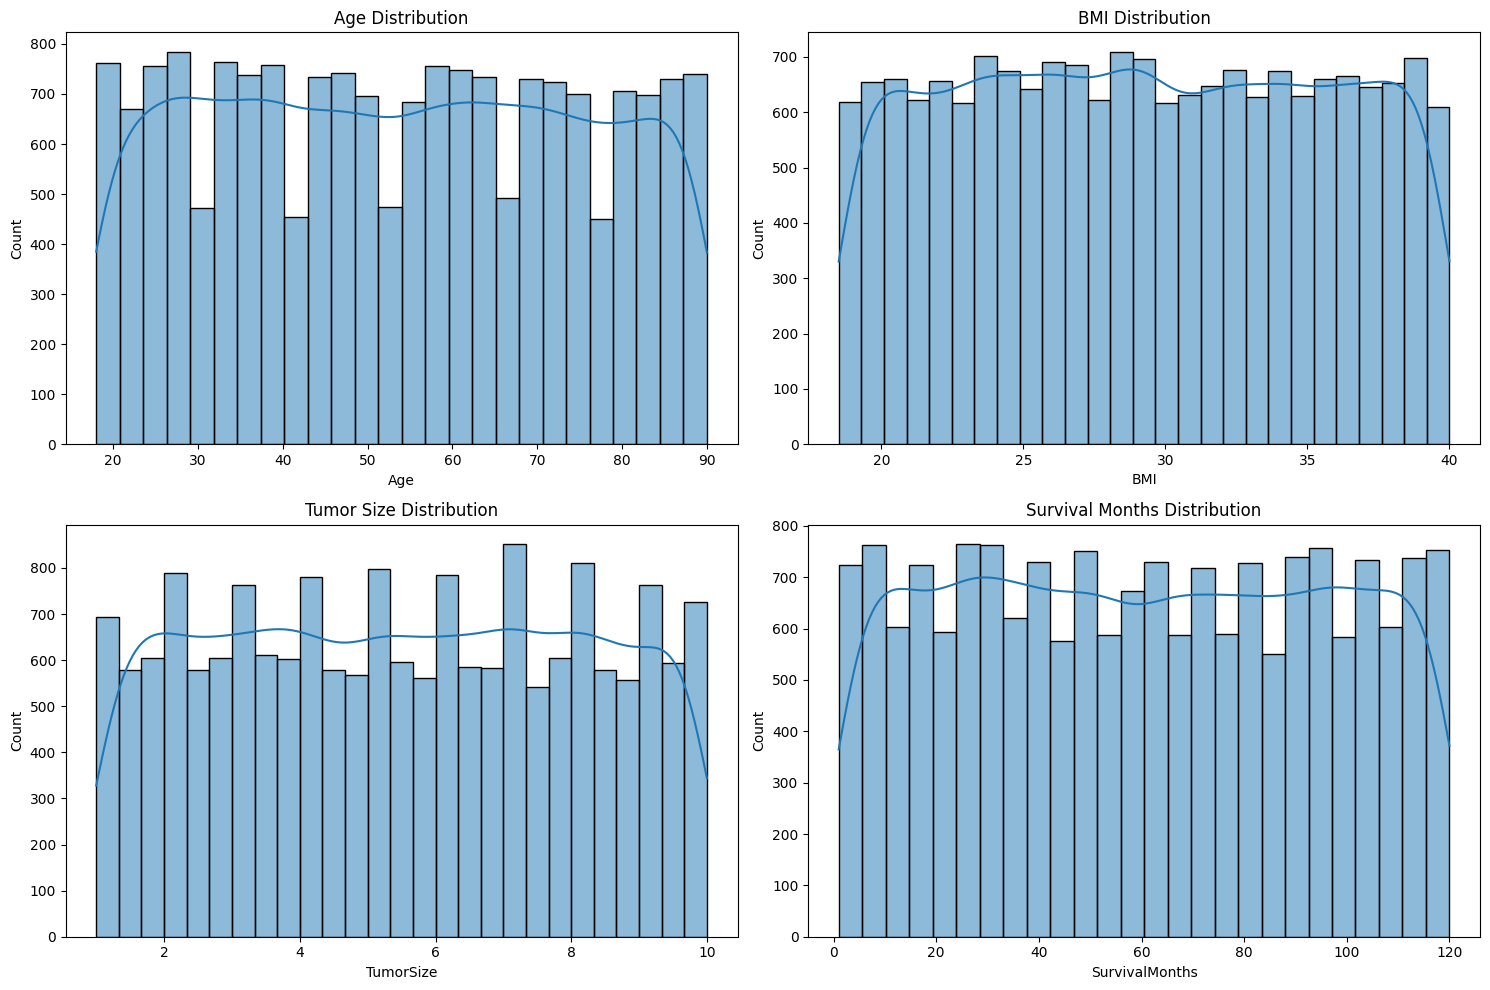

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['Age'], kde=True, ax=axes[0, 0]).set_title('Age Distribution')
sns.histplot(df['BMI'], kde=True, ax=axes[0, 1]).set_title('BMI Distribution')
sns.histplot(df['TumorSize'], kde=True, ax=axes[1, 0]).set_title('Tumor Size Distribution')
sns.histplot(df['SurvivalMonths'], kde=True, ax=axes[1, 1]).set_title('Survival Months Distribution')

plt.tight_layout()
plt.show()